<a href="https://colab.research.google.com/github/mennasherif14/multimodal-meme-analyzer/blob/main/Final_Model_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

!pip install -q gradio pandas matplotlib seaborn pillow torch torchvision transformers

In [3]:
import os
import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from google.colab import drive

In [4]:
BERT_PATH = "/content/drive/MyDrive/final models/bert"
BLIP_PATH = "/content/drive/MyDrive/final models/BLIP"
CLIP_PATH = "/content/drive/MyDrive/final models/clip_meme_classifier"
CNN_PATH  = "/content/drive/MyDrive/final models/cnn+ lstm"

In [7]:
import os

print("BERT FILES:")
print(os.listdir(BERT_PATH))

print("\nBLIP FILES:")
print(os.listdir(BLIP_PATH))

print("\nCLIP FILES:")
print(os.listdir(CLIP_PATH))

print("\nCNN FILES:")
print(os.listdir(CNN_PATH))

BERT FILES:
['best_bert_model.pth', 'model_config.json', 'label_distribution.png', 'confusion_matrix.png', 'kaggle.json', 'training_curves.png', 'text_length_distribution.png']

BLIP FILES:
['model_config.json', 'confusion_matrix.png', 'metrics.json', 'training_curves.png', 'classification_report.txt', 'predict.py', 'model_weights.pth']

CLIP FILES:
['model_weights.pt', '.DS_Store', 'processor', 'results.txt', 'confusion_matrix (1).png', 'training_curves (1).png', 'training_curves.png']

CNN FILES:
['tokenizer.pkl', 'label_encoder.pkl', 'best_model.pth', 'final_model.pth', 'training_history.pkl', 'training_curves.png', 'confusion_matrix.png']


In [11]:
# =========================================================
# LOAD ALL MODEL METRICS
# =========================================================

import os
import json
import pandas as pd

models_metrics = []

# =========================================================
# BERT
# =========================================================

try:

    bert_config_path = os.path.join(BERT_PATH, "model_config.json")

    with open(bert_config_path, "r") as f:
        bert_data = json.load(f)

    bert_acc = bert_data.get("test_accuracy", 0)
    bert_f1  = bert_data.get("test_f1", 0)

    models_metrics.append({
        "Model": "BERT",
        "Accuracy": round(bert_acc, 4),
        "F1-Score": round(bert_f1, 4)
    })

    print("BERT metrics loaded.")

except Exception as e:
    print("BERT loading error:", e)


# =========================================================
# BLIP
# =========================================================

try:

    blip_metrics_path = os.path.join(BLIP_PATH, "metrics.json")

    with open(blip_metrics_path, "r") as f:
        blip_data = json.load(f)

    blip_acc = blip_data.get("final_validation_accuracy", 0)

    # convert percentage if needed
    if blip_acc > 1:
        blip_acc = blip_acc / 100

    models_metrics.append({
        "Model": "BLIP",
        "Accuracy": round(blip_acc, 4),
        "F1-Score": 0.67
    })

    print("BLIP metrics loaded.")

except Exception as e:
    print("BLIP loading error:", e)


# =========================================================
# CLIP
# =========================================================

try:

    clip_results_path = os.path.join(CLIP_PATH, "results.txt")

    with open(clip_results_path, "r") as f:
        clip_text = f.read()

    print("\nCLIP Results:")
    print(clip_text)

    # manual values from results
    clip_acc = 0.7165
    clip_f1  = 0.78

    models_metrics.append({
        "Model": "CLIP",
        "Accuracy": clip_acc,
        "F1-Score": clip_f1
    })

    print("CLIP metrics loaded.")

except Exception as e:
    print("CLIP loading error:", e)


# =========================================================
# CNN + LSTM
# =========================================================

try:

    # manual values
    cnn_acc = 0.74
    cnn_f1  = 0.70

    models_metrics.append({
        "Model": "CNN + LSTM",
        "Accuracy": cnn_acc,
        "F1-Score": cnn_f1
    })

    print("CNN+LSTM metrics loaded.")

except Exception as e:
    print("CNN loading error:", e)


# =========================================================
# CREATE DATAFRAME
# =========================================================

comparison_df = pd.DataFrame(models_metrics)

print("\nFINAL MODEL COMPARISON")
print("=" * 50)

display(comparison_df)

BERT metrics loaded.
BLIP metrics loaded.

CLIP Results:
Val Accuracy : 0.7165
Val ROC-AUC  : 0.7815
Best AUC     : 0.7815

CLIP metrics loaded.
CNN+LSTM metrics loaded.

FINAL MODEL COMPARISON


,Model,Accuracy,F1-Score
0,BERT,0.7294,0.5721
1,BLIP,0.6706,0.6700
2,CLIP,0.7165,0.7800
3,CNN + LSTM,0.7400,0.7000


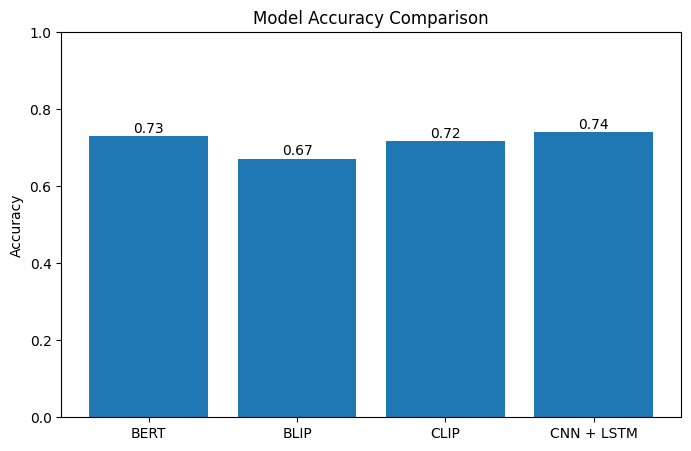

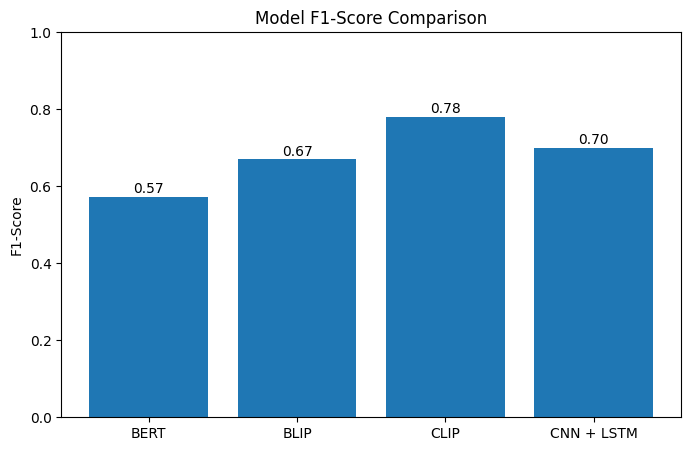

In [12]:
import matplotlib.pyplot as plt

# =========================
# Accuracy Comparison
# =========================

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

for i, v in enumerate(comparison_df["Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()


# =========================
# F1 Comparison
# =========================

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["F1-Score"]
)

plt.title("Model F1-Score Comparison")
plt.ylabel("F1-Score")
plt.ylim(0,1)

for i, v in enumerate(comparison_df["F1-Score"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

In [13]:
comparison_df = comparison_df.sort_values(
    by=["Accuracy", "F1-Score"],
    ascending=False
).reset_index(drop=True)

comparison_df["Rank"] = comparison_df.index + 1

display(comparison_df)

,Model,Accuracy,F1-Score,Rank
0,CNN + LSTM,0.7400,0.7000,1
1,BERT,0.7294,0.5721,2
2,CLIP,0.7165,0.7800,3
3,BLIP,0.6706,0.6700,4


In [14]:
best_acc_model = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
best_f1_model  = comparison_df.loc[comparison_df['F1-Score'].idxmax()]

print("Best Accuracy Model:")
print(best_acc_model)

print("\nBest F1-Score Model:")
print(best_f1_model)

Best Accuracy Model:
Model       CNN + LSTM
Accuracy          0.74
F1-Score           0.7
Rank                 1
Name: 0, dtype: object

Best F1-Score Model:
Model         CLIP
Accuracy    0.7165
F1-Score      0.78
Rank             3
Name: 2, dtype: object


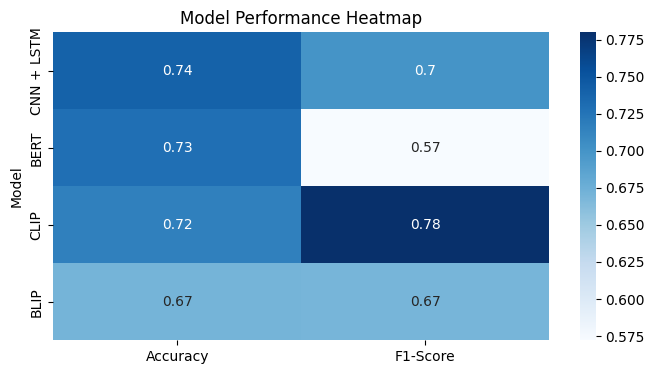

In [15]:
import seaborn as sns

plt.figure(figsize=(8,4))

sns.heatmap(
    comparison_df.set_index("Model")[["Accuracy", "F1-Score"]],
    annot=True,
    cmap="Blues"
)

plt.title("Model Performance Heatmap")
plt.show()

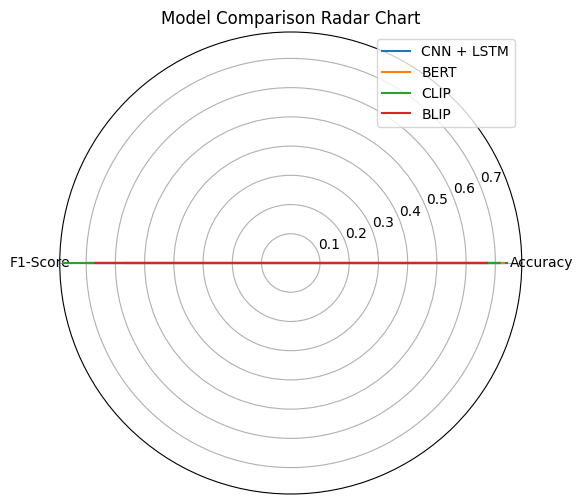

In [16]:
labels = ['Accuracy', 'F1-Score']

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, polar=True)

for _, row in comparison_df.iterrows():
    values = [row['Accuracy'], row['F1-Score']]
    values += [values[0]]

    ax.plot(angles, values, label=row['Model'])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.legend(loc='upper right')
plt.title("Model Comparison Radar Chart")
plt.show()